<a href="https://colab.research.google.com/github/Albertomhz01/MNE-analysis/blob/main/Analysis_P001S001_Fixation-ERP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analysis multi run: P001S001 R02 to R05 - Fix -> Inflating**

A generalized version of the single-run analysis. Each run is preprocessed independently (bad channel detection, filtering, average referencing, ICA), and the epochs from the four runs are then concatenated into a single `Epochs` object to run the cluster-based permutation test on the complete dataset.

The reason for separate preprocessing is that bad channels differ across runs (e.g., Fp2 in R04, and T8 in R03 and R05), and the average reference would be contaminated if calculated based on the raw concatenation.

In [1]:
!pip install -q numpy pandas matplotlib scipy mne autoreject BCI2kReader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 30.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from BCI2kReader import BCI2kReader as b2k
from autoreject import AutoReject
from mne.channels import find_ch_adjacency
from mne.stats import permutation_cluster_1samp_test
import warnings

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

# **Settings**

In [3]:
# Root where all the ".dat files are
ROOT = "/content/"
# Name of all the P001 runs
RUNS = [
    "P001S001R02",
    "P001S001R03",
    "P001S001R04",
    "P001S001R05",
]

# PressureTarget in mmHg -> condition label
TARGET_MAP = {8: "none", 46: "low", 111: "high"}

# Time window studied in the ERP
TMIN = -0.5
TMAX = 1.0
BASELINE = (-0.2, 0.0)

# Low and High Frequency Filters
L_FREQ = 0.1
H_FREQ = 40.0

# 256 / 2 = 128 Hz, Nyquist 64 Hz, well above the 40 Hz low pass, it can be 256 / 3
DECIM = 2

# Z-score threshold used to identify bad or abnormal channels.
# Raised from 3.5 to 5.0. With 32 channels the MAD is small and 3.5 flags
# normal channels as bad.
Z_THRESH_BAD = 5.0
# Channels excluded from the variance criterion, their variance is ocular
EOG_LIKE = ("Fp1", "Fp2")
# Number of permutations used in permutation-based statistical tests
N_PERMUTATIONS = 1000
# Random seed to make the analysis reproducible
SEED = 97

# Region of interest for a visual evoked response
OCCIPITAL_ROI = ["O1", "O2", "PO7", "PO8", "PO3", "PO4"]

# **Auxiliary functions**

## **Unit conversion**

`mne.io.read_raw_bci2k` reads the samples as stored and does not apply `SourceChGain`
or `SourceChOffset`. The conversion is therefore only valid when the gain is 1, which
is the case in these recordings. `check_units` asserts it instead of assuming it.

In [4]:
def to_volts(x):
    """The stored values are already microvolts when SourceChGain is 1, MNE expects volts"""
    return x * 1e-6

# Sanity check
def check_units(path):
    """Read SourceChGain and SourceChOffset from the header and confirm the 1e-6 scaling."""
    with b2k.BCI2kReader(path) as reader:
        gains = [float(g) for g in reader.parameters["SourceChGain"]]
        offsets = [float(o) for o in reader.parameters["SourceChOffset"]]

    ok = all(g == 1.0 for g in gains) and all(o == 0.0 for o in offsets)

    if not ok:
        raise ValueError(
            "SourceChGain is not 1 or SourceChOffset is not 0 in this file. "
            "read_raw_bci2k does not apply them, so to_volts would give wrong "
            "amplitudes. Gains: " + str(sorted(set(gains)))
        )

    return True

## **Automatic detection of bad channels**

The detection runs on **band-pass filtered** data. The amplifier is DC coupled, so before filtering the standard deviation of every channel sits in the tens of thousands of microvolts and is dominated by drift. Ranking channels by that number does not say anything about data quality.

Fp1 and Fp2 are removed from the variance criterion because their variance comes from blinks. For those two channels only a flat or saturated test is applied, which is what actually identifies a disconnected electrode.

**The criterion applied:** *robust z-score based on the standard deviation of each channel using MAD, and flat-channel test.*

In [5]:
def detect_bad_channels(raw, z_thresh=Z_THRESH_BAD):
    # Channels judged by variance, frontal poles excluded
    picks = []
    for name in raw.ch_names:
        if name not in EOG_LIKE:
            picks.append(name)

    data = raw.copy().pick(picks).get_data()

    # Calculate the signal variability for each channel
    std_per_channel = np.std(data, axis=1)

     # Use the median and MAD (Median Absolute Deviation) for robust outlier detection
    median_std = np.median(std_per_channel)
    mad = np.median(np.abs(std_per_channel - median_std))

    bads = []

    # Calculate the robust (modified) z-score for each channel
    if mad > 0:
        robust_z = 0.6745 * (std_per_channel - median_std) / mad

        for i in range(len(picks)):
            is_outlier = abs(robust_z[i]) > z_thresh
            is_flat = std_per_channel[i] < 0.05 * median_std

            if is_outlier or is_flat:
                bads.append(picks[i])

    # Frontal poles, flat or saturated only
    all_data = raw.get_data()
    all_std = np.std(all_data, axis=1)
    all_median = np.median(all_std)

    for name in EOG_LIKE:
        if name in raw.ch_names:
            i = raw.ch_names.index(name)
            if all_std[i] < 0.05 * all_median or all_std[i] > 50 * all_median:
                bads.append(name)

    return bads

A channel is considered **bad** if it has either:

- **Abnormal variability:** its robust z-score satisfies \(|z| > 5.0\).
- **A nearly flat signal:** its standard deviation is less than 5% of the median standard deviation across channels.

These criteria identify channels with unusually noisy or unusually low-variability signals.

# **Loading a run**

Reads the `.dat` file, adds the stimulus channel derived from `StimulusPhase`, extracts the events, and also returns the raw states needed later to label the condition of each trial.

In [6]:
def load_run(run_name):
    path = f"{ROOT}/{run_name}.dat"

    check_units(path)

    raw = mne.io.read_raw_bci2k(path, preload=True)

    with b2k.BCI2kReader(path) as reader:
        phase_state = reader.states["StimulusPhase"].ravel()
        trial_state = reader.states["TrialNumber"].ravel()
        target_state = reader.states["PressureTarget"].ravel()
        ch_names = list(reader.parameters["ChannelNames"])

    # Drop the stim channel that read_raw_bci2k adds from StimulusCode, it is unused here
    eeg_only = []
    for name in raw.ch_names:
        if name.startswith("EEG"):
            eeg_only.append(name)
    raw.pick(eeg_only)

    rename = {}
    for i in range(len(eeg_only)):
        rename[eeg_only[i]] = ch_names[i]

    raw.rename_channels(rename)
    raw.set_montage(mne.channels.make_standard_montage("standard_1020"))

    # Convert once, at load time, so everything downstream is in volts
    raw.apply_function(to_volts, picks="eeg")

    return raw, phase_state, trial_state, target_state

# **Fixation events and trial labelling**

The rising edge into `StimulusPhase == 0` marks the fixation onset.

The trial id is read at the **end** of the fixation window and not at its onset. On the first trial
of every run the controller writes `TrialNumber` roughly one and a half seconds after the fixation
has already started, so reading it at the onset returned 0 and the trial was thrown away together
with the calibration cycle. The true calibration cycle never produces a rising edge because the
recording already starts inside phase 0, so it is excluded automatically.

In [7]:
def fixation_events(phase_state, trial_state, target_state):
    onsets = []
    for i in range(1, len(phase_state)):
        if phase_state[i] == 0 and phase_state[i - 1] != 0:
            onsets.append(i)

    events = []
    trials = []
    conditions = []

    for start in onsets:
        end = start
        while end < len(phase_state) and phase_state[end] == 0:
            end = end + 1

        # Trial id at the end of the fixation window
        trial_num = int(trial_state[end - 1])

        # Calibration cycle
        if trial_num == 0:
            continue

        hold_mask = (trial_state == trial_num) & (phase_state == 2)
        if hold_mask.sum() == 0:
            continue

        dominant_target = int(pd.Series(target_state[hold_mask]).mode()[0])
        if dominant_target not in TARGET_MAP:
            continue

        events.append([start, 0, 1])
        trials.append(trial_num)
        conditions.append(TARGET_MAP[dominant_target])

    return np.array(events, dtype=int), trials, conditions

# **Preprocessing**

Order matters here. Filter first, then detect bad channels on the filtered signal, then interpolate,
then average reference. Interpolating before referencing is what keeps a single disconnected
electrode from contaminating all 32 channels, which is what happened with Fp2 in R04.

`reset_bads=True` is kept so the four runs end with identical `info` and can be concatenated.

In [8]:
def preprocess(raw):
    # Band-pass first
    raw.filter(l_freq = L_FREQ, h_freq = H_FREQ, picks = "eeg")

    # Detect on the filtered signal
    bads = detect_bad_channels(raw)
    raw.info["bads"] = bads

    # Interpolate bad channels
    if len(bads) > 0:
        raw.interpolate_bads(reset_bads = True)

    raw.set_eeg_reference("average", projection = True)

    return bads

# **ICA for blinks**

Unchanged. The EOG proxy is chosen codnitionally and the components come from `find_bads_eog` rathen than a fixed index

In [9]:
def run_ica(raw, bads):
    # ICA works better with a 1 Hz high-pass filter
    raw_ica = raw.copy().filter(l_freq=1.0, h_freq=None, picks="eeg")

    # ICA
    ica = mne.preprocessing.ICA(
        n_components=20,
        random_state=SEED,
        max_iter="auto",
    )
    ica.fit(raw_ica, picks="eeg")

    # Select a frontal channel as an EOG proxy (Fp1 or Fp2)
    for candidate in ["Fp1", "Fp2"]:
        if candidate not in bads:
            eog_proxy = candidate
            break

    # Find bad EOG
    eog_indices, eog_scores = ica.find_bads_eog(
        raw_ica,
        ch_name=eog_proxy,
        threshold=2.5
    )
    ica.exclude = eog_indices

    # Apply ICA
    raw_clean = raw.copy()
    if len(eog_indices) > 0:
        ica.apply(raw_clean)

    return raw_clean, eog_indices, eog_proxy

# **EPOCHING**

`proj=True` applies the average reference projection at epoch creation. The condition labels
come straight from `hold_events`, so no second pass over the states is needed.

In [10]:
def build_epochs(raw_clean, events, trials, conditions, run_name):
    epochs = mne.Epochs(
        raw_clean,
        events,
        event_id = {"fixation": 1},
        tmin = TMIN,
        tmax = TMAX,
        baseline = BASELINE,
        preload = True,
        decim = DECIM,
        proj = True,
    )

    epochs.metadata = pd.DataFrame({
        "run": [run_name] * len(trials),
        "trial": trials,
        "condition": conditions,
    })

    return epochs

# **Marker timing check**

This has to be looked at before any ERP is interpreted. BCI2000 updates the state vector once per
sample block, and `SampleBlockSize = 32` at 256 Hz means one block is 125 ms. If every fixation
onset falls exactly on a multiple of 32 samples, then the marker does not carry sub-block timing and
the real screen onset can be anywhere inside a 125 ms window after it, plus whatever the monitor and
the operating system add on top.

In [11]:
timing_rows = []

# Sanity check
for run_name in RUNS:
    path = f"{ROOT}/{run_name}.dat"

    with b2k.BCI2kReader(path) as reader:
        phase_state = reader.states["StimulusPhase"].ravel()
        block_size = int(reader.parameters["SampleBlockSize"])
        sfreq = float(reader.parameters["SamplingRate"])

    onsets = []
    for ii in range(1, len(phase_state)):
        if phase_state[ii] == 0 and phase_state[ii - 1] != 0:
            onsets.append(ii)

    remainders = sorted(set([o % block_size for o in onsets]))

    timing_rows.append({
        "run": run_name,
        "block_size": block_size,
        "block_ms": 1000.0 * block_size / sfreq,
        "n_fixation_onsets": len(onsets),
        "onset_remainders_mod_block": str(remainders),
    })

timing_df = pd.DataFrame(timing_rows)
timing_df

,run,block_size,block_ms,n_fixation_onsets,onset_remainders_mod_block
0,P001S001R02,32,125.0,30,[0]
1,P001S001R03,32,125.0,30,[0]
2,P001S001R04,32,125.0,30,[0]
3,P001S001R05,32,125.0,30,[0]


"¿El timestamp que BCI2000 está dando como inicio de fixation corresponde al momento real en que la cruz apareció en la pantalla, o simplemente al límite del bloque de 125 ms?"

En este caso si.

In [12]:
# Are the digital input lines carrying anything? If they are all zero there is no hardware trigger.
with b2k.BCI2kReader(f"{ROOT}/{RUNS[0]}.dat") as reader:
    for name in ["DigitalInput1", "StimulusTime"]:
        if name in reader.states:
            values = np.unique(reader.states[name].ravel())
            print(f"{name}: {len(values)} distinct value(s), min {values.min()}, max {values.max()}")

DigitalInput1: 1 distinct value(s), min 0, max 0
StimulusTime: 1 distinct value(s), min 0, max 0


# **Processing the 4 runs**

In [13]:
epochs_by_run = []
diagnostics = []

for run_name in RUNS:
    print(f"Procesando {run_name} ...")

    raw, phase_state, trial_state, target_state = load_run(run_name)
    events, trials, conditions = fixation_events(phase_state, trial_state, target_state)

    bads = preprocess(raw)
    raw_clean, eog_indices, eog_proxy = run_ica(raw, bads)

    epochs = build_epochs(raw_clean, events, trials, conditions, run_name)

    counts = epochs.metadata["condition"].value_counts()
    diagnostics.append({
        "run": run_name,
        "n_fixation_events": len(events),
        "bad_channels": ", ".join(bads) if bads else "-",
        "eog_proxy": eog_proxy,
        "ica_excluded": ", ".join(str(i) for i in eog_indices) if len(eog_indices) else "-",
        "n_epochs": len(epochs),
        "none": int(counts.get("none", 0)),
        "low": int(counts.get("low", 0)),
        "high": int(counts.get("high", 0)),
    })

    epochs_by_run.append(epochs)

    del raw, raw_clean

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df

Procesando P001S001R02 ...


Procesando P001S001R03 ...


Procesando P001S001R04 ...


Procesando P001S001R05 ...


,run,n_fixation_events,bad_channels,eog_proxy,ica_excluded,n_epochs,none,low,high
0,P001S001R02,30,-,Fp1,0,30,10,10,10
1,P001S001R03,30,"T8, P4",Fp1,0,30,10,10,10
2,P001S001R04,30,"F4, Fp2",Fp1,0,30,10,10,10
3,P001S001R05,30,"FC6, P4, O1",Fp1,0,30,10,10,10


# **Concatanate the runs**

In [14]:
epochs_all = mne.concatenate_epochs(epochs_by_run)

print(epochs_all)
print("shape:", epochs_all.get_data().shape)
print("sfreq:", epochs_all.info["sfreq"], "Hz")
print("window:", epochs_all.times[0], "to", epochs_all.times[-1], "s")
print()
print(epochs_all.metadata["condition"].value_counts())

<EpochsArray | 120 events (all good), -0.5 – 1 s (baseline -0.2 – 0 s), ~5.7 MiB, data loaded, with metadata,
 'fixation': 120>
shape: (120, 32, 193)
sfreq: 128.0 Hz
window: -0.5 to 1.0 s

condition
high    40
none    40
low     40
Name: count, dtype: int64


# **AutoReject on the combined set**

Run once across all epochs instead of four times across 30. With more epochs, the internal cross-validation estimates more stable channel-specific thresholds.

In [15]:
ar = AutoReject(
    random_state = SEED,
    n_jobs = 1,
    verbose = False,
)

epochs_clean, reject_log = ar.fit_transform(epochs_all, return_log = True)

print(f"Kept {len(epochs_clean)} / {len(epochs_all)} epochs")
print()
print(epochs_clean.metadata.groupby(["run", "condition"]).size().unstack(fill_value = 0))

Kept 109 / 120 epochs

condition    high  low  none
run                         
P001S001R02    10   10     8
P001S001R03    10   10    10
P001S001R04     6    8    10
P001S001R05    10    9     8


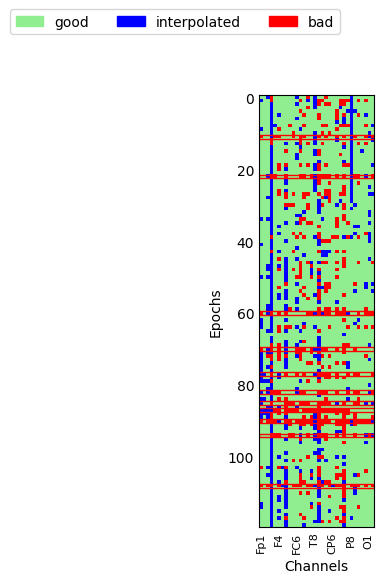

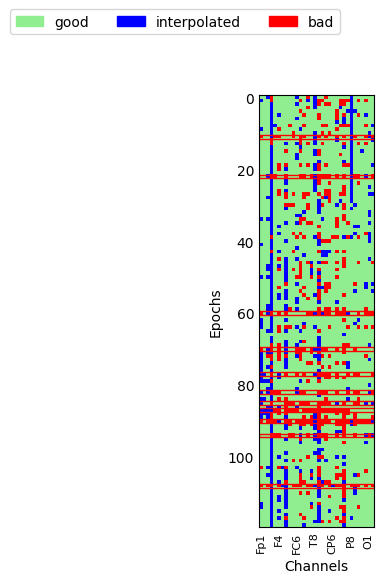

In [16]:
reject_log.plot()

# **Checking balance after rejection**

In [17]:
balance = epochs_clean.metadata["condition"].value_counts()
print(balance)

if balance.max() - balance.min() > 0.2 * balance.max():
    print()
    print(f"WARNING: imbalance greater than 20 percent between conditions")

condition
low     37
high    36
none    36
Name: count, dtype: int64


# **The fixation ERP**

`plot_joint` is the single most useful plot here, because the topography at the peak is what says whether the deflection is a visual evoked response or an artifact. A visual response must be positive over occipital and parietal sites with the opposite sign frontally.

<Evoked | 'fixation' (average, N=109), -0.5 – 1 s, baseline -0.2 – 0 s, 32 ch, ~91 KiB>


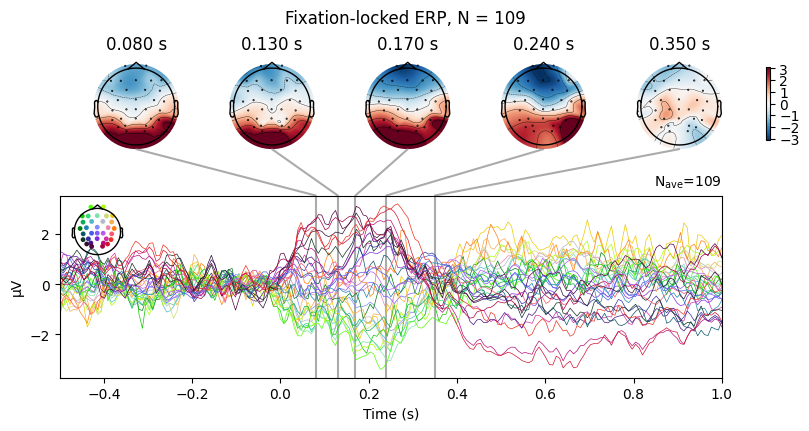

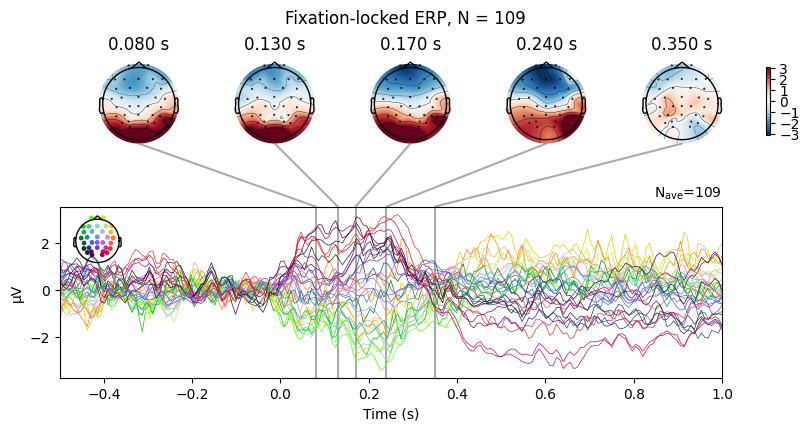

In [18]:
fixation_evoked = epochs_clean.average()
print(fixation_evoked)

fixation_evoked.plot_joint(
    times = [0.08, 0.13, 0.17, 0.24, 0.35],
    title = f"Fixation-locked ERP, N = {len(epochs_clean)}",
)

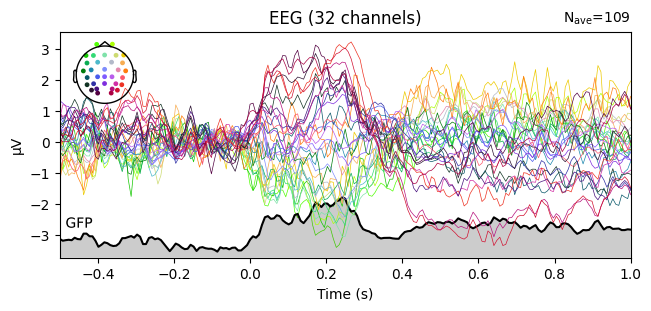

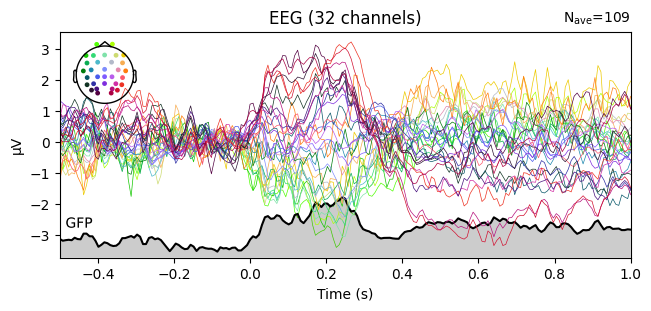

In [19]:
fixation_evoked.plot(spatial_colors = True, gfp = True)

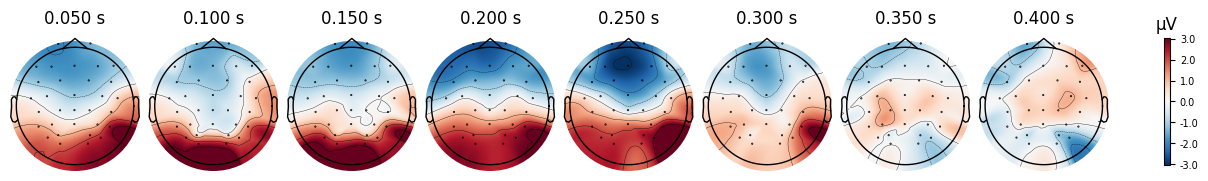

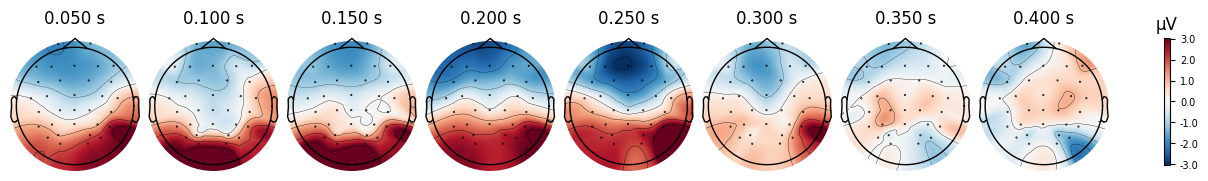

In [20]:
fixation_evoked.plot_topomap(times = np.arange(0.05, 0.45, 0.05), ch_type = "eeg")

# **Occipital region of interest (ROI)**

Averaging across all 32 channels the way `combine = "mean" as in previous coding versions, because the frontal and posterior sites have opposite polarity and cancel. The response has to be read on a posterior region of interest

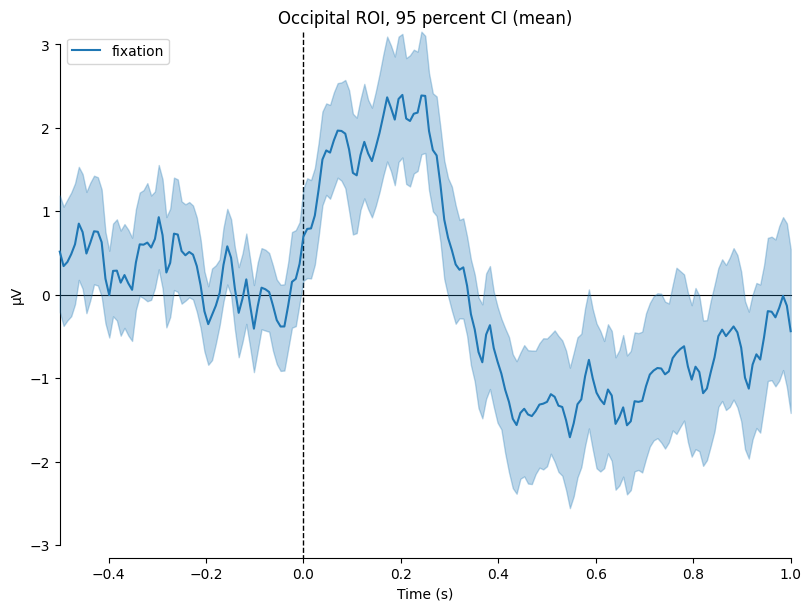

[<Figure size 800x600 with 1 Axes>]

In [21]:
roi = []
for name in OCCIPITAL_ROI:
    if name in epochs_clean.ch_names:
        roi.append(name)

mne.viz.plot_compare_evokeds(
    {"fixation": list(epochs_clean.iter_evoked())},
    picks = roi,
    combine = "mean",
    title = "Occipital ROI, 95 percent CI",
)

# **Single trials**

The image plot shows whether the average is carried by all trials or by a handful of large ones.

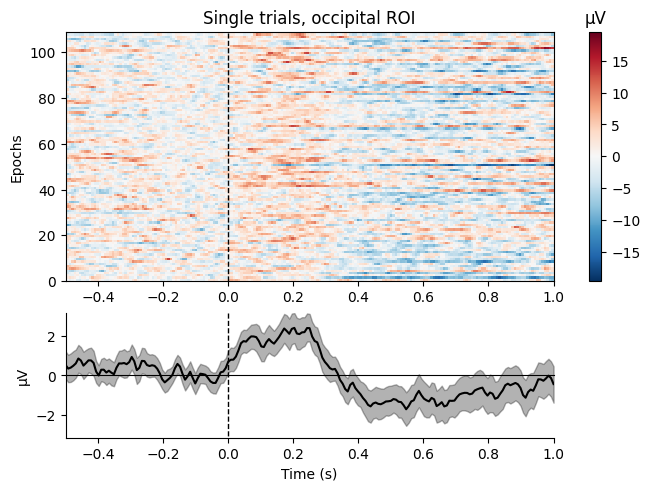

[<Figure size 640x480 with 3 Axes>]

In [22]:
epochs_clean.plot_image(
    picks=roi,
    combine="mean",
    title="Single trials, occipital ROI"
)

# **Validation**

4 independent checks that the deflection is a real time-locked response and not noise.

## **1. Split-half reliabilit**

Split the epochs in two havles at random and correlate the two averages over the response window. An unreliable average gives a correlation near zero.

In [23]:
rng = np.random.RandomState(SEED)
roi_data = epochs_clean.get_data(picks = roi).mean(axis = 1) * 1e6
times = epochs_clean.times

order = rng.permutation(len(epochs_clean))
half_a = order[0::2]
half_b = order[1::2]

window = (times >= 0.5) & (times <= 0.45)
r = np.corrcoef(roi_data[half_a].mean(axis=0)[window],
                roi_data[half_b].mean(axis=0)[window])[0, 1]

print(f"Split-half correlation of the occipital ERP, 50 to 450 ms: r = {r:.3f}")

Split-half correlation of the occipital ERP, 50 to 450 ms: r = nan


## **2. Surrogate test**

Each epoch is circularly shifted by a random amount and the average is recomputed. That destroys the time locking while preserving the spectrum and the amplitude of every trial. The peak of the real average is then compared against the distribution of surrogate peaks.

Real peak: 2.395 uV
Surrogate 95th percentile: 1.099 uV
p = 0.0020


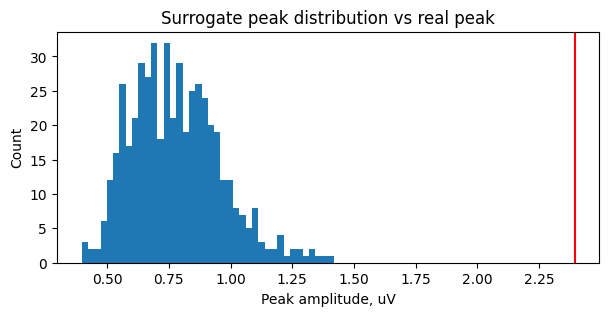

In [24]:
window = (times >= 0.0) & (times <= 0.4)
real_peak = np.abs(roi_data.mean(axis=0)[window]).max()

surrogate_peaks = []
for i in range(500):
    shifted = np.zeros(roi_data.shape)
    for j in range(len(roi_data)):
        shifted[j] = np.roll(roi_data[j], rng.randint(len(times)))
    surrogate_peaks.append(np.abs(shifted.mean(axis=0)[window]).max())

surrogate_peaks = np.array(surrogate_peaks)
p_value = (np.sum(surrogate_peaks >= real_peak) + 1) / (len(surrogate_peaks) + 1)

print(f"Real peak: {real_peak:.3f} uV")
print(f"Surrogate 95th percentile: {np.percentile(surrogate_peaks, 95):.3f} uV")
print(f"p = {p_value:.4f}")

plt.figure(figsize=(7, 3))
plt.hist(surrogate_peaks, bins=40)
plt.axvline(real_peak, color="red")
plt.xlabel("Peak amplitude, uV")
plt.ylabel("Count")
plt.title("Surrogate peak distribution vs real peak")
plt.show()

## **3. Cluster permutation against zero**

A one sample cluster test across all 32 channels and the whole epoch. This is the version of the
test that answers "is there a response at all", which is the question being asked here. The three
condition test is not the right tool for it, because at fixation onset no pressure has been applied
yet and the conditions cannot differ.

In [25]:
data_for_test = epochs_clean.get_data() * 1e6
adjacency, ch_names_adj = find_ch_adjacency(epochs_clean.info, ch_type="eeg")

t_obs, clusters, cluster_p, h0 = permutation_cluster_1samp_test(
    data_for_test.transpose(0, 2, 1),
    n_permutations=N_PERMUTATIONS,
    adjacency=adjacency,
    tail=0,
    seed=SEED,
    out_type="mask",
)

found = False
for i in range(len(cluster_p)):
    if cluster_p[i] < 0.05:
        found = True
        time_idx = np.where(clusters[i].any(axis=1))[0]
        ch_idx = np.where(clusters[i].any(axis=0))[0]
        names = [epochs_clean.ch_names[k] for k in ch_idx]
        print(f"cluster p = {cluster_p[i]:.4f}   "
              f"{1000 * times[time_idx[0]]:.0f} to {1000 * times[time_idx[-1]]:.0f} ms   "
              f"{len(names)} channels: {', '.join(names)}")

if not found:
    print("No significant cluster")

cluster p = 0.0010   -8 to 375 ms   17 channels: C3, T8, CP5, CP1, CP2, CP6, P7, P3, Pz, P4, P8, PO7, PO3, PO4, PO8, O1, O2
cluster p = 0.0110   344 to 727 ms   11 channels: Fp2, Fz, F4, F8, FC1, FC2, FC6, Cz, C4, T8, CP2
cluster p = 0.0010   0 to 406 ms   15 channels: Fp1, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, Cz, C4, T7, CPz
cluster p = 0.0010   352 to 1000 ms   11 channels: CP5, P7, P3, Pz, P4, P8, PO7, PO3, PO4, PO8, O2


## **4. Negative control, the upcoming condition**

Each fixation is labelled with the condition of the trial that is about to start. Nothing has been
applied to the participant yet, so the three curves must overlap. If they separate, something in the
pipeline is leaking condition information backwards in time.

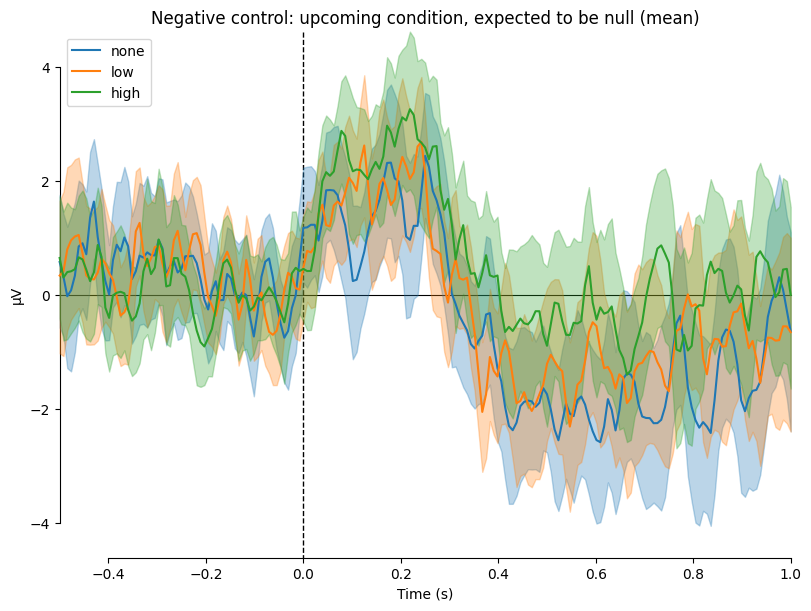

[<Figure size 800x600 with 1 Axes>]

In [26]:
by_condition = {}
for condition in ["none", "low", "high"]:
    by_condition[condition] = list(epochs_clean[f"condition == '{condition}'"].iter_evoked())

mne.viz.plot_compare_evokeds(
    by_condition,
    picks=roi,
    combine="mean",
    title="Negative control: upcoming condition, expected to be null",
)

## **5. Consistency across runs**

The four runs were recorded separately. The same response should appear in each of them. Large
differences in peak latency between runs point at marker timing rather than at physiology.

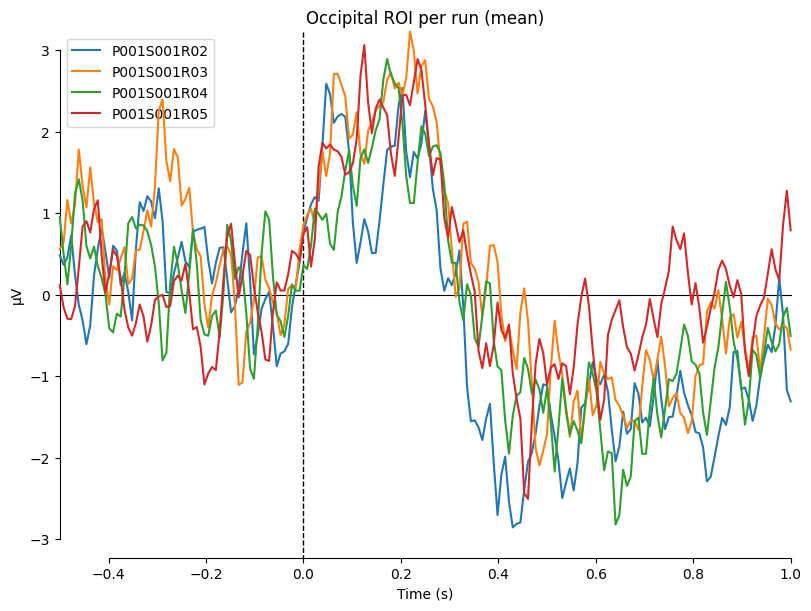

P001S001R02  n=28  peak +2.59 uV at 47 ms
P001S001R03  n=30  peak +3.23 uV at 219 ms
P001S001R04  n=24  peak +2.89 uV at 172 ms
P001S001R05  n=27  peak +3.06 uV at 125 ms


In [27]:
by_run = {}
for run_name in RUNS:
    by_run[run_name] = epochs_clean[f"run == '{run_name}'"].average()

mne.viz.plot_compare_evokeds(
    by_run,
    picks = roi,
    combine = "mean",
    title = "Occipital ROI per run",
)

for run_name in RUNS:
    data = by_run[run_name].get_data(picks=roi).mean(axis = 0) * 1e6
    window = (times >= 0.0) & (times <= 0.4)
    peak = data[window].max()
    latency = 1000 * times[window][np.argmax(data[window])]
    print(f"{run_name}  n={len(epochs_clean[f'run == \'{run_name}\''])}  "
          f"peak {peak:+.2f} uV at {latency:.0f} ms")